In [12]:
from mil.CellsData import CellsData


import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

import numpy as np

from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

from sklearn.linear_model import LogisticRegression, RidgeClassifier, RidgeClassifierCV, LassoCV, LogisticRegressionCV
from sklearn.model_selection import cross_validate, train_test_split

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import  StratifiedKFold


import warnings
warnings.filterwarnings("ignore", module="sklearn")


In [2]:
train_set = CellsData(split="train")
val_set = CellsData(split="val")
test_set = CellsData(split="test")

/home/viktor/Documents/mil_project/MIL/mil/CellsData.py:69: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  self.X[index] = torch.sparse_coo_tensor(


In [3]:
#train set
X_sparse_max = []
X_sparse_mean = []

X_embed_max = []
X_embed_mean = []

y_train = []

#test set
X_test_sparse_max = []
X_test_sparse_mean = []

X_test_embed_max = []
X_test_embed_mean = []

y_test = []

for el in train_set:
    X_sparse_max.append(np.max(el['bag'].to_dense().numpy(), axis = 0))
    X_sparse_mean.append(np.sum(el['bag'].to_dense().numpy(), axis = 0))

    X_embed_max.append(np.max(el['bag_embed'].to_dense().numpy(), axis = 0))
    X_embed_mean.append(np.sum(el['bag_embed'].to_dense().numpy(), axis = 0))

    y_train.append(el['y'].numpy())

for el in val_set:
    X_sparse_max.append(np.max(el['bag'].to_dense().numpy(), axis = 0))
    X_sparse_mean.append(np.sum(el['bag'].to_dense().numpy(), axis = 0))

    X_embed_max.append(np.max(el['bag_embed'].to_dense().numpy(), axis = 0))
    X_embed_mean.append(np.sum(el['bag_embed'].to_dense().numpy(), axis = 0))

    y_train.append(el['y'].numpy())

for el in test_set:
    X_test_sparse_max.append(np.max(el['bag'].to_dense().numpy(), axis = 0))
    X_test_sparse_mean.append(np.sum(el['bag'].to_dense().numpy(), axis = 0))

    X_test_embed_max.append(np.max(el['bag_embed'].to_dense().numpy(), axis = 0))
    X_test_embed_mean.append(np.sum(el['bag_embed'].to_dense().numpy(), axis = 0))

    y_test.append(el['y'].numpy())

X_sparse_max = np.array(X_sparse_max)
X_sparse_mean = np.array(X_sparse_mean)

X_embed_max = np.array(X_embed_max)
X_embed_mean = np.array(X_embed_mean)

y_train = np.array(y_train)[:, 1]

#test set
X_test_sparse_max = np.array(X_test_sparse_max)
X_test_sparse_mean = np.array(X_test_sparse_mean)

X_test_embed_max = np.array(X_test_embed_max)
X_test_embed_mean = np.array(X_embed_mean)

y_test = np.array(y_test)[:, 1]

In [4]:
result_dict = dict()
clfs = dict()
options = dict()

options['Ridge'] = RidgeClassifierCV(alphas = (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000), cv = 5, class_weight='balanced', fit_intercept = True)
options['Lasso'] = LogisticRegressionCV(penalty='l1', Cs = (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000), cv = 5, solver='saga', max_iter = 1000)
options['Elastic Net'] = LogisticRegressionCV(penalty='elasticnet', Cs = (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000), l1_ratios = [0.1, 0.5, 1], cv = 5, solver='saga', max_iter = 1000)
options['SVM'] = SVC(C = 100, class_weight='balanced')
options['Tree'] = DecisionTreeClassifier(max_depth = 30, class_weight='balanced')
options['Random Forest'] = RandomForestClassifier(n_estimators = 50, max_depth = 5, class_weight='balanced')



for classifier in options.keys():
    clf = options[classifier]
    scores = cross_validate(
        clf, X_sparse_max, y_train, scoring="balanced_accuracy", cv=StratifiedKFold(n_splits=5, shuffle=True)
    )

    print(classifier)
    mean = scores["test_score"].mean()
    sem = stats.sem(scores["test_score"])

    print(f"Mean Balanced Accuracy: {mean:.3f} +/- {sem:.3f}")
    acc_random = 0.125
    print(f"Balanced Accuracy with Random Labels: {acc_random:.3f}")

    result_dict[classifier] = (mean, sem)
    clfs[classifier] = clf


/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.999636781301888e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.14588156319951e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.741527406958994e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.74

Ridge
Mean Balanced Accuracy: 0.495 +/- 0.024
Balanced Accuracy with Random Labels: 0.125


/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit

Lasso
Mean Balanced Accuracy: 0.464 +/- 0.039
Balanced Accuracy with Random Labels: 0.125


/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means

Elastic Net
Mean Balanced Accuracy: 0.470 +/- 0.030
Balanced Accuracy with Random Labels: 0.125
SVM
Mean Balanced Accuracy: 0.492 +/- 0.044
Balanced Accuracy with Random Labels: 0.125
Tree
Mean Balanced Accuracy: 0.615 +/- 0.042
Balanced Accuracy with Random Labels: 0.125
Random Forest
Mean Balanced Accuracy: 0.551 +/- 0.051
Balanced Accuracy with Random Labels: 0.125


/tmp/ipykernel_1685629/1019223800.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_1685629/1019223800.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(('0%', '20%', '40%', '60%', '80%', '100%'))


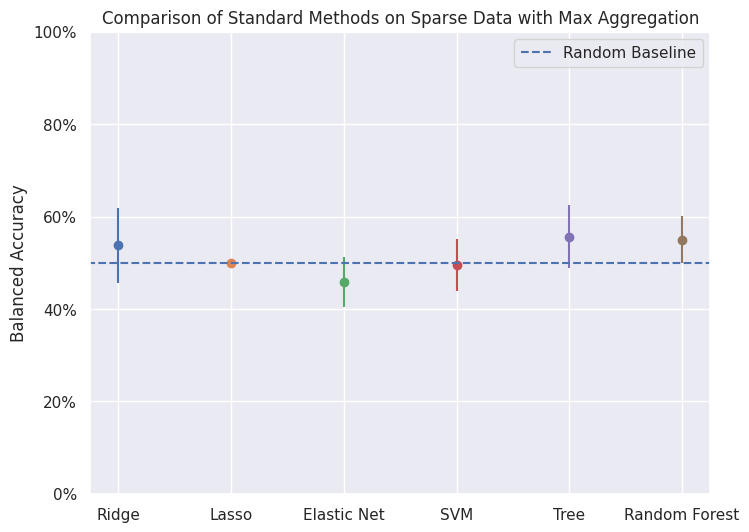

In [13]:
fig, ax = plt.subplots(figsize = (8, 6))

counter = 0
for key, value in result_dict.items():
        ax.scatter(counter, value[0])
        ax.errorbar(counter, value[0], 1.96*value[1])
        counter +=1


ax.set_ylim((0, 1))
ax.legend()

ax.set_title("Comparison of Standard Methods on Sparse Data with Max Aggregation")
ax.set_xticks(range(len(result_dict.keys())))
ax.set_xticklabels(result_dict.keys())
ax.set_ylabel('Balanced Accuracy')
ax.set_yticklabels(('0%', '20%', '40%', '60%', '80%', '100%'))
ax.axhline(0.5, xmin=-1, xmax = 5, linestyle = '--', label = 'Random Baseline')
ax.legend()

In [6]:
result_dict = dict()
clfs = dict()
options = dict()

options['Ridge'] = RidgeClassifierCV(alphas = (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000), cv = 5, class_weight='balanced', fit_intercept = True)
options['Lasso'] = LogisticRegressionCV(penalty='l1', Cs = (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000), cv = 5, solver='saga', max_iter = 1000)
options['Elastic Net'] = LogisticRegressionCV(penalty='elasticnet', Cs = (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000), l1_ratios = [0.1, 0.5, 1], cv = 5, solver='saga', max_iter = 1000)
options['SVM'] = SVC(C = 100, class_weight='balanced')
options['Tree'] = DecisionTreeClassifier(max_depth = 30, class_weight='balanced')
options['Random Forest'] = RandomForestClassifier(n_estimators = 50, max_depth = 5, class_weight='balanced')



for classifier in options.keys():
    clf = options[classifier]
    scores = cross_validate(
        clf, X_sparse_mean, y_train, scoring="balanced_accuracy", cv=StratifiedKFold(n_splits=5, shuffle=True)
    )

    print(classifier)
    mean = scores["test_score"].mean()
    sem = stats.sem(scores["test_score"])

    print(f"Mean Balanced Accuracy: {mean:.3f} +/- {sem:.3f}")
    acc_random = 0.125
    print(f"Balanced Accuracy with Random Labels: {acc_random:.3f}")

    result_dict[classifier] = (mean, sem)
    clfs[classifier] = clf


/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:267: UserWarning: S

Ridge
Mean Balanced Accuracy: 0.477 +/- 0.023
Balanced Accuracy with Random Labels: 0.125


/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means

Lasso
Mean Balanced Accuracy: 0.546 +/- 0.061
Balanced Accuracy with Random Labels: 0.125


/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn

Elastic Net
Mean Balanced Accuracy: 0.628 +/- 0.043
Balanced Accuracy with Random Labels: 0.125
SVM
Mean Balanced Accuracy: 0.530 +/- 0.039
Balanced Accuracy with Random Labels: 0.125
Tree
Mean Balanced Accuracy: 0.490 +/- 0.039
Balanced Accuracy with Random Labels: 0.125
Random Forest
Mean Balanced Accuracy: 0.564 +/- 0.044
Balanced Accuracy with Random Labels: 0.125


/tmp/ipykernel_1685629/569535037.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_1685629/569535037.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(('0%', '20%', '40%', '60%', '80%', '100%'))


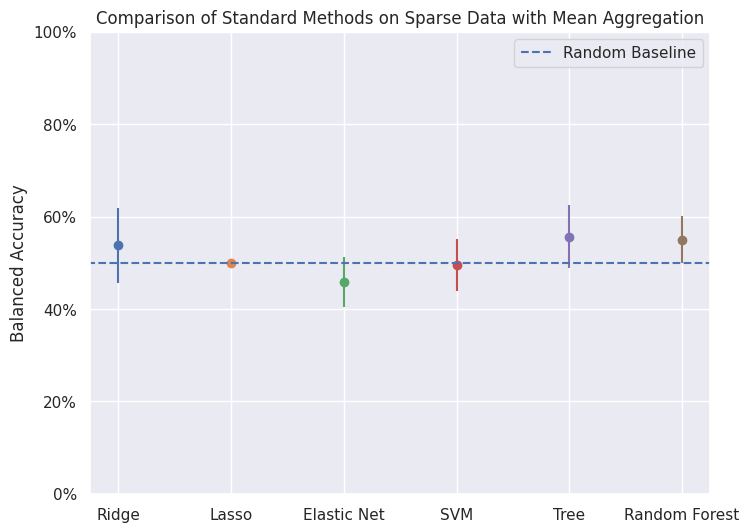

In [14]:
fig, ax = plt.subplots(figsize = (8, 6))

counter = 0
for key, value in result_dict.items():
    ax.scatter(counter, value[0])
    ax.errorbar(counter, value[0], 1.96*value[1])
    counter +=1

ax.set_ylim((0, 1))
ax.legend()

ax.set_title("Comparison of Standard Methods on Sparse Data with Mean Aggregation")
ax.set_xticks(range(len(result_dict.keys())))
ax.set_xticklabels(result_dict.keys())
ax.set_ylabel('Balanced Accuracy')
ax.set_yticklabels(('0%', '20%', '40%', '60%', '80%', '100%'))
ax.axhline(0.5, xmin=-1, xmax = 5, linestyle = '--', label = 'Random Baseline')
ax.legend()

In [15]:
result_dict = dict()
clfs = dict()
options = dict()

options['Ridge'] = RidgeClassifierCV(alphas = (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000), cv = 5, class_weight='balanced', fit_intercept = True)
options['Lasso'] = LogisticRegressionCV(penalty='l1', Cs = (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000), cv = 5, solver='saga', max_iter = 1000)
options['Elastic Net'] = LogisticRegressionCV(penalty='elasticnet', Cs = (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000), l1_ratios = [0.1, 0.5, 1], cv = 5, solver='saga', max_iter = 1000)
options['SVM'] = SVC(C = 100, class_weight='balanced')
options['Tree'] = DecisionTreeClassifier(max_depth = 30, class_weight='balanced')
options['Random Forest'] = RandomForestClassifier(n_estimators = 50, max_depth = 5, class_weight='balanced')



for classifier in options.keys():
    clf = options[classifier]
    scores = cross_validate(
        clf, X_embed_max, y_train, scoring="balanced_accuracy", cv=StratifiedKFold(n_splits=5, shuffle=True)
    )

    print(classifier)
    mean = scores["test_score"].mean()
    sem = stats.sem(scores["test_score"])

    print(f"Mean Balanced Accuracy: {mean:.3f} +/- {sem:.3f}")
    acc_random = 0.125
    print(f"Balanced Accuracy with Random Labels: {acc_random:.3f}")

    result_dict[classifier] = (mean, sem)
    clfs[classifier] = clf

Ridge
Mean Balanced Accuracy: 0.530 +/- 0.038
Balanced Accuracy with Random Labels: 0.125
Lasso
Mean Balanced Accuracy: 0.481 +/- 0.019
Balanced Accuracy with Random Labels: 0.125
Elastic Net
Mean Balanced Accuracy: 0.469 +/- 0.026
Balanced Accuracy with Random Labels: 0.125
SVM
Mean Balanced Accuracy: 0.521 +/- 0.026
Balanced Accuracy with Random Labels: 0.125
Tree
Mean Balanced Accuracy: 0.561 +/- 0.052
Balanced Accuracy with Random Labels: 0.125
Random Forest
Mean Balanced Accuracy: 0.490 +/- 0.039
Balanced Accuracy with Random Labels: 0.125


/tmp/ipykernel_1685629/1788208335.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_1685629/1788208335.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(('0%', '20%', '40%', '60%', '80%', '100%'))


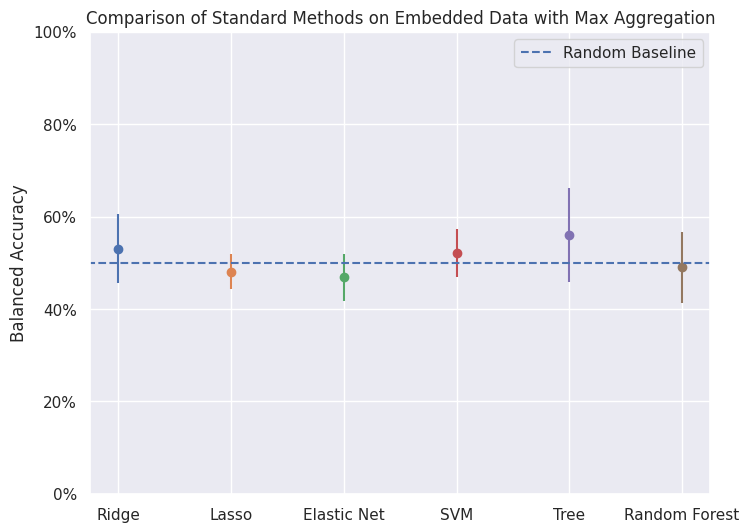

In [16]:
fig, ax = plt.subplots(figsize = (8, 6))

counter = 0
for key, value in result_dict.items():
    ax.scatter(counter, value[0])
    ax.errorbar(counter, value[0], 1.96*value[1])
    counter +=1


ax.set_ylim((0, 1))
ax.legend()

ax.set_title("Comparison of Standard Methods on Embedded Data with Max Aggregation")
ax.set_xticks(range(len(result_dict.keys())))
ax.set_xticklabels(result_dict.keys())
ax.set_ylabel('Balanced Accuracy')
ax.set_yticklabels(('0%', '20%', '40%', '60%', '80%', '100%'))
ax.axhline(0.5, xmin=-1, xmax = 5, linestyle = '--', label = 'Random Baseline')
ax.legend()

In [10]:
result_dict = dict()
clfs = dict()
options = dict()

options['Ridge'] = RidgeClassifierCV(alphas = (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000), cv = 5, class_weight='balanced', fit_intercept = True)
options['Lasso'] = LogisticRegressionCV(penalty='l1', Cs = (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000), cv = 5, solver='saga', max_iter = 1000)
options['Elastic Net'] = LogisticRegressionCV(penalty='elasticnet', Cs = (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000), l1_ratios = [0.1, 0.5, 1], cv = 5, solver='saga', max_iter = 1000)
options['SVM'] = SVC(C = 100, class_weight='balanced')
options['Tree'] = DecisionTreeClassifier(max_depth = 30, class_weight='balanced')
options['Random Forest'] = RandomForestClassifier(n_estimators = 50, max_depth = 5, class_weight='balanced')



for classifier in options.keys():
    clf = options[classifier]
    scores = cross_validate(
        clf, X_embed_max, y_train, scoring="balanced_accuracy", cv=StratifiedKFold(n_splits=5, shuffle=True)
    )

    print(classifier)
    mean = scores["test_score"].mean()
    sem = stats.sem(scores["test_score"])

    print(f"Mean Balanced Accuracy: {mean:.3f} +/- {sem:.3f}")
    acc_random = 0.125
    print(f"Balanced Accuracy with Random Labels: {acc_random:.3f}")

    result_dict[classifier] = (mean, sem)
    clfs[classifier] = clf

Ridge
Mean Balanced Accuracy: 0.538 +/- 0.041
Balanced Accuracy with Random Labels: 0.125


/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit

Lasso
Mean Balanced Accuracy: 0.500 +/- 0.000
Balanced Accuracy with Random Labels: 0.125


/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/home/viktor/Documents/mil_project/MIL/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn

Elastic Net
Mean Balanced Accuracy: 0.458 +/- 0.028
Balanced Accuracy with Random Labels: 0.125
SVM
Mean Balanced Accuracy: 0.495 +/- 0.029
Balanced Accuracy with Random Labels: 0.125
Tree
Mean Balanced Accuracy: 0.556 +/- 0.035
Balanced Accuracy with Random Labels: 0.125
Random Forest
Mean Balanced Accuracy: 0.550 +/- 0.026
Balanced Accuracy with Random Labels: 0.125


/tmp/ipykernel_1685629/410841661.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_1685629/410841661.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(('0%', '20%', '40%', '60%', '80%', '100%'))


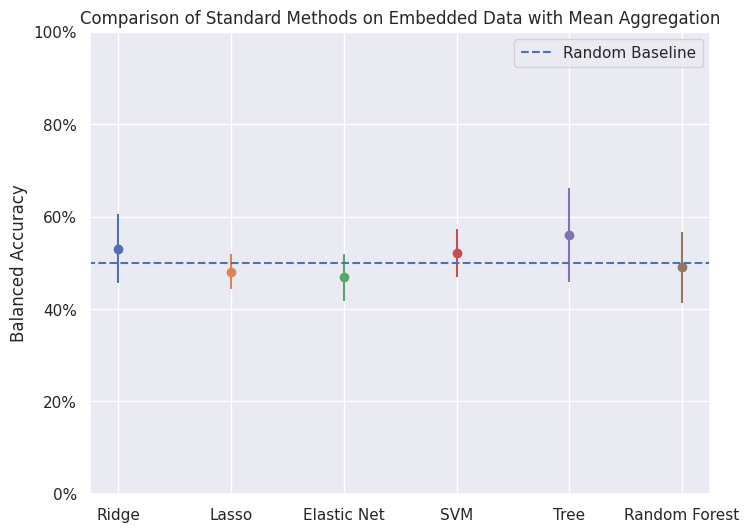

In [17]:
fig, ax = plt.subplots(figsize = (8, 6))

counter = 0
for key, value in result_dict.items():
    ax.scatter(counter, value[0])
    ax.errorbar(counter, value[0], 1.96*value[1])
    counter +=1


ax.set_ylim((0, 1))
ax.legend()

ax.set_title("Comparison of Standard Methods on Embedded Data with Mean Aggregation")
ax.set_xticks(range(len(result_dict.keys())))
ax.set_xticklabels(result_dict.keys())
ax.set_ylabel('Balanced Accuracy')
ax.set_yticklabels(('0%', '20%', '40%', '60%', '80%', '100%'))
ax.axhline(0.5, xmin=-1, xmax = 5, linestyle = '--', label = 'Random Baseline')
ax.legend()